# Map of seasonal range of the tracers

In [2]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import PathPatch


import xarray as xr
import numpy as np
import matplotlib as mpl
from matplotlib import gridspec
import matplotlib.path as mpath
import matplotlib.colors as mcolors

from matplotlib import ticker, cm
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.ticker as mticker
import cmcrameri
import cmocean.cm as cmocean
import intake
import dask.distributed as dask


In [3]:
from os import environ
environ["PYTHONWARNINGS"] = "ignore"

In [4]:
client = dask.Client(threads_per_worker = 1)
client


/g/data/xp65/public/apps/med_conda/envs/analysis3-26.01/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 45717 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/45717/status,
Dashboard: /proxy/45717/status,Workers: 24
Total threads: 24,Total memory: 95.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:40705,Workers: 0
Dashboard: /proxy/45717/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:44545,Total threads: 1
Dashboard: /proxy/42379/status,Memory: 3.96 GiB
Nanny: tcp://127.0.0.1:33497,


In [18]:
figdir = '/g/data/x77/ps7863/figures/AABW_variability/bottom_500m/'
# session = cc.database.create_session('/g/data/ik11/databases/cosima_master.db')
catalog = intake.cat.access_nri
iaf_cycle3 = '01deg_jra55v140_iaf_cycle3'
expt = '01deg_jra55v140_iaf_cycle3_antarctic_tracers'

In [6]:
# lon_slice = slice(80-360, 190-360)
lat_slice = slice(-82, -55)

degree =  u'\N{DEGREE SIGN}'

In [7]:
var='ht'
ht = catalog[iaf_cycle3].search(
    variable=var
).to_dask()
ht = ht['ht']



/g/data/xp65/public/apps/med_conda/envs/analysis3-26.01/lib/python3.11/site-packages/intake_esm/source.py:308: ConcatenationWarning: Attempting to concatenate datasets without valid dimension coordinates: retaining only first dataset. Request valid dimension coordinate to silence this warning.
  warnings.warn(


In [8]:
land_mask = np.squeeze(ht.values)
land_mask = land_mask * 0
land_mask[np.isnan(land_mask)] = 1
yt_ocean =ht.yt_ocean.values
xt_ocean =ht.xt_ocean.values
land_mask_masked = np.ma.masked_where((land_mask==0),land_mask)

In [9]:
shelf_mask = ht > 1000
shelf_mask = shelf_mask.astype(bool)
masked_shelf = shelf_mask.where(shelf_mask==0, np.nan)
shelf_mask = shelf_mask.where(shelf_mask==1, np.nan)
shelf_mask

<xarray.DataArray 'ht' (yt_ocean: 2700, xt_ocean: 3600)> Size: 78MB
dask.array<where, shape=(2700, 3600), dtype=float64, chunksize=(540, 720), chunktype=numpy.ndarray>
Coordinates:
  * yt_ocean  (yt_ocean) float64 22kB -81.11 -81.07 -81.02 ... 89.89 89.94 89.98
  * xt_ocean  (xt_ocean) float64 29kB -279.9 -279.8 -279.7 ... 79.75 79.85 79.95

In [10]:
xt_ocean = ht.xt_ocean
yt_ocean = ht.yt_ocean

In [11]:
X, Y = np.meshgrid(xt_ocean, yt_ocean)
X = xr.DataArray(X, coords=[yt_ocean, xt_ocean], dims=['yt_ocean', 'xt_ocean'])
Y = xr.DataArray(Y, coords=[yt_ocean, xt_ocean], dims=['yt_ocean', 'xt_ocean'])

In [12]:
def make_boundary_path(longitudes, latitudes):
    """
    Return a path around boundary to create a sector map, then cut it out given
    longitudes and latitudes.
    """

    boundary_path = np.array([longitudes[-1, :], latitudes[-1, :]])
    boundary_path = np.append(
        boundary_path, np.array([longitudes[::-1, -1], latitudes[::-1, -1]]), axis=1
    )
    boundary_path = np.append(
        boundary_path, np.array([longitudes[1, ::-1], latitudes[1, ::-1]]), axis=1
    )
    boundary_path = np.append(
        boundary_path, np.array([longitudes[:, 1], latitudes[:, 1]]), axis=1
    )
    boundary_path = mpath.Path(np.swapaxes(boundary_path, 0, 1))

    return boundary_path

In [13]:
# To plot 1000-m contour
contour_file = np.load('/g/data/ik11/grids/Antarctic_slope_contour_1000m.npz')
shelf = contour_file['contour_masked_above']
yt_ocean = contour_file['yt_ocean']
xt_ocean = contour_file['xt_ocean']
# Mask values that are non-zero
shelf[np.where(shelf!=0)] = np.nan
shelf = shelf+1
shelf = np.nan_to_num(shelf)
shelf = xr.DataArray(shelf, coords = [('yt_ocean', yt_ocean), ('xt_ocean', xt_ocean)])

In [14]:
land_50m = cfeature.NaturalEarthFeature(
    "physical", "land", "50m", edgecolor="black", facecolor="grey", linewidth=0.5
)

In [15]:
# Define projection regions with correct orientation
regions = {
    "Ross": {
        "midlon": -210, "minlon": -240, "maxlon": -180,
        "minlat": -76, "maxlat": -60
    },
    "Weddell": {
        "midlon": -40, "minlon": -60, "maxlon": -20,
        "minlat": -76, "maxlat": -60
    },
    "Adelie": {
        "midlon": -230, "minlon": -250, "maxlon": -210,
        "minlat": -70, "maxlat": -60
    },
    "Prydz": {
        "midlon": 55, "minlon": 35, "maxlon": 75,
        "minlat": -70, "maxlat": -60
    }
}

In [16]:
albw_range = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/bottom_500m/ALBW_range_detrended_1968-2018.nc')
rsbw_range =xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/bottom_500m/RSBW_range_detrended_1968-2018.nc')
wsbw_range = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/bottom_500m/WSBW_range_detrended_1968-2018.nc')
cdbw_range = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/bottom_500m/PBBW_range_detrended_1968-2018.nc')

In [17]:
albw_range = albw_range['ALBW_range']
rsbw_range = rsbw_range['RSBW_range']
wsbw_range = wsbw_range['WSBW_range']
cdbw_range = cdbw_range['PBBW_range']

NameError: name 'pbbw_range' is not defined

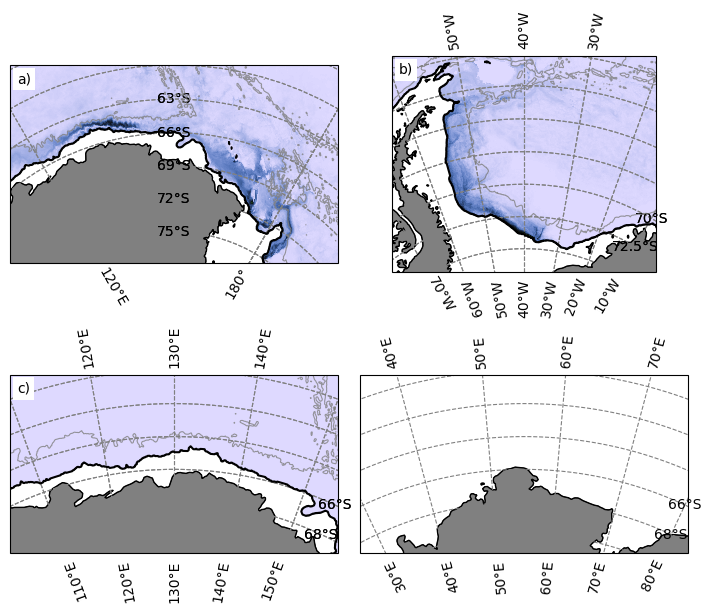

In [19]:
# Set up figure and GridSpec (2 rows x 3 columns)
fig = plt.figure(figsize=(7, 6), constrained_layout=True)
gs = gridspec.GridSpec(2, 2, figure=fig)

norm = mcolors.TwoSlopeNorm(vmin=0, vcenter=0.08, vmax=0.16)
cmap = cmcrameri.cm.tofino

# Map region to subplot position (row, col)
subplot_positions = {
    "Ross":  (0, 0),  # Span 2 columns
    "Weddell": (0, 1),
    "Adelie":  (1, 0),
    "Prydz":   (1, 1)
}
fontsize=10
    
# Plot each region
for name, pos in subplot_positions.items():
    r = regions[name]
    proj = ccrs.Stereographic(central_latitude=-90, central_longitude=r["midlon"])
    ax = fig.add_subplot(gs[pos], projection=proj)

    ax.add_feature(land_50m)
    ax.coastlines(resolution="50m")
    ax.set_extent([r["minlon"], r["maxlon"], r["minlat"], r["maxlat"]], crs=ccrs.PlateCarree())
    ax.gridlines(draw_labels=True, linestyle='--', color='grey')
    ax.spines['geo'].set_visible(True) 
    # Clean frame
    # gl = ax.gridlines(draw_labels=False)
    # ax.set_frame_on(False)

    if name=='Ross':
        pc=ax.pcolormesh(rsbw_range.xt_ocean+360, rsbw_range.yt_ocean, rsbw_range, cmap=cmap, norm=norm, transform=ccrs.PlateCarree())
        ax.annotate(
        'a)',
        xy=(0, 1), xycoords='axes fraction',
        xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize=fontsize, verticalalignment='top', fontfamily='sans-serif',
        bbox=dict(facecolor='white', edgecolor='none', pad=3.0))
    if name=='Weddell':
        pc=ax.pcolormesh(wsbw_range.xt_ocean+360, wsbw_range.yt_ocean, wsbw_range, cmap=cmap, norm=norm, transform=ccrs.PlateCarree()) 
        ax.annotate(
        'b)',
        xy=(0, 1), xycoords='axes fraction',
        xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize=fontsize, verticalalignment='top', fontfamily='sans-serif',
        bbox=dict(facecolor='white', edgecolor='none', pad=3.0))
    if name=='Adelie':
        pc=ax.pcolormesh(albw_range.xt_ocean+360, albw_range.yt_ocean, albw_range, cmap=cmap, norm=norm, transform=ccrs.PlateCarree())
        ax.annotate(
        'c)',
        xy=(0, 1), xycoords='axes fraction',
        xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize=fontsize, verticalalignment='top', fontfamily='sans-serif',
        bbox=dict(facecolor='white', edgecolor='none', pad=3.0))
    if name=='Prydz':
        pc=ax.pcolormesh(pbbw_range.xt_ocean+360, pbbw_range.yt_ocean, pbbw_range, cmap=cmap, norm=norm, transform=ccrs.PlateCarree())
        ax.annotate(
        'd)',
        xy=(0, 1), xycoords='axes fraction',
        xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize=fontsize, verticalalignment='top', fontfamily='sans-serif',
        bbox=dict(facecolor='white', edgecolor='none', pad=3.0))

    gl = ax.gridlines(draw_labels=True, linestyle='--', color='grey')
    gl.right_labels = False
    gl.top_labels = False
    gl.bottom_labels = False
    gl.left_labels = True
    
    # Move y-axis (latitude) labels outside
    ax.tick_params(axis='y', which='both', direction='out', pad=5)
    
    # Control x-axis labels position
    if pos[0] == 0:  # Top row
        ax.tick_params(axis='x', which='both', top=True, labeltop=True,
                       bottom=False, labelbottom=False)
    else:  # Bottom row
        ax.tick_params(axis='x', which='both', top=False, labeltop=False,
                       bottom=True, labelbottom=True) 
    ax.contour(shelf.xt_ocean, shelf.yt_ocean,shelf,
                [0.5],
                colors = 'k',
                linewidths = 1.5,
                transform=ccrs.PlateCarree())

    ax.contour(ht.xt_ocean, ht.yt_ocean, ht,
                    levels=[3500],
                    colors='grey',
                    linewidths=.8,
                    alpha=.8,
                    transform=ccrs.PlateCarree())
    ax.contourf(shelf.xt_ocean, shelf.yt_ocean, shelf, [0.5, 1], transform=ccrs.PlateCarree(), colors='white')

cbar_ax1 = fig.add_axes([0, 0.5, 0.25, 0.015])  # [left, bottom, width, height]

cbar1 = plt.colorbar(pc, cax=cbar_ax1,
                     orientation='horizontal',
                     spacing='proportional',
                     ticks=[0, 0.04, 0.08, 0.12, 0.16],
                     extend='max',
                     location='bottom'
                    )
cbar1.set_label('Tracer concentration', fontsize=12)




plt.savefig(f'{figdir}/tracers_seasonal_range_1968-2018.png', dpi=300, bbox_inches='tight')


In [29]:
albw_mean= xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/bottom_500m/albw_detrended_mean_1968-2018.nc')
rsbw_mean = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/bottom_500m/rsbw_detrended_mean_1968-2018.nc')
wsbw_mean = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/bottom_500m/wsbw_detrended_mean_1968-2018.nc')
cdbw_mean = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/bottom_500m/pbbw_detrended_mean_1968-2018.nc')



In [30]:
albw_mean = albw_mean['ALBW mean concentration']
rsbw_mean = rsbw_mean['RSBW mean concentration']
wsbw_mean = wsbw_mean['WSBW mean concentration']
cdbw_mean = cdbw_mean['PBBW mean concentration']

In [31]:
albw_range_rel = albw_range / albw_mean * 100
rsbw_range_rel = rsbw_range / rsbw_mean  * 100
wsbw_range_rel = wsbw_range / wsbw_mean  * 100
cdbw_range_rel = pbbw_range / cdbw_mean * 100

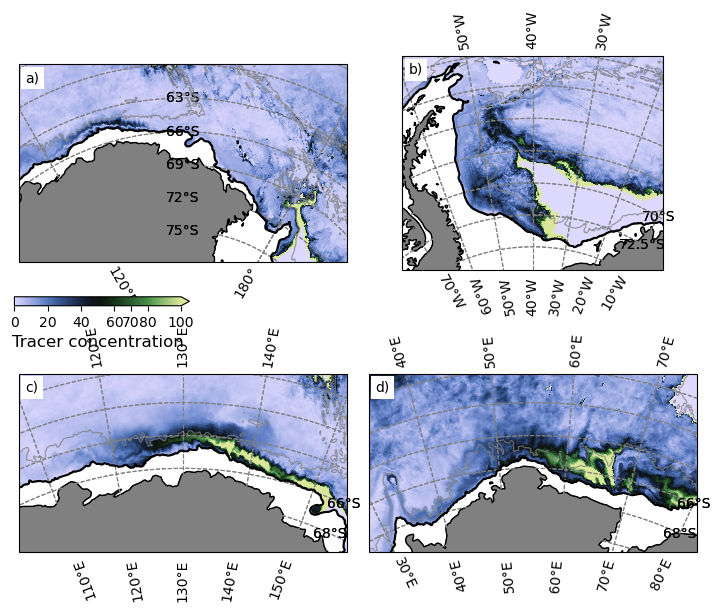

In [33]:
# Set up figure and GridSpec (2 rows x 3 columns)
fig = plt.figure(figsize=(7, 6), constrained_layout=True)
gs = gridspec.GridSpec(2, 2, figure=fig)

norm = mcolors.TwoSlopeNorm(vmin=0, vcenter=50, vmax=100)
cmap = cmcrameri.cm.tofino

# Map region to subplot position (row, col)
subplot_positions = {
    "Ross":  (0, 0),  # Span 2 columns
    "Weddell": (0, 1),
    "Adelie":  (1, 0),
    "Prydz":   (1, 1)
}
fontsize=10
    
# Plot each region
for name, pos in subplot_positions.items():
    r = regions[name]
    proj = ccrs.Stereographic(central_latitude=-90, central_longitude=r["midlon"])
    ax = fig.add_subplot(gs[pos], projection=proj)

    ax.add_feature(land_50m)
    ax.coastlines(resolution="50m")
    ax.set_extent([r["minlon"], r["maxlon"], r["minlat"], r["maxlat"]], crs=ccrs.PlateCarree())
    ax.gridlines(draw_labels=True, linestyle='--', color='grey')
    ax.spines['geo'].set_visible(True) 
    # Clean frame
    # gl = ax.gridlines(draw_labels=False)
    # ax.set_frame_on(False)

    if name=='Ross':
        pc=ax.pcolormesh(rsbw_range_rel.xt_ocean+360, rsbw_range_rel.yt_ocean, rsbw_range_rel, cmap=cmap, norm=norm, transform=ccrs.PlateCarree())
        ax.annotate(
        'a)',
        xy=(0, 1), xycoords='axes fraction',
        xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize=fontsize, verticalalignment='top', fontfamily='sans-serif',
        bbox=dict(facecolor='white', edgecolor='none', pad=3.0))
    if name=='Weddell':
        pc=ax.pcolormesh(wsbw_range_rel.xt_ocean+360, wsbw_range_rel.yt_ocean, wsbw_range_rel, cmap=cmap, norm=norm, transform=ccrs.PlateCarree()) 
        ax.annotate(
        'b)',
        xy=(0, 1), xycoords='axes fraction',
        xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize=fontsize, verticalalignment='top', fontfamily='sans-serif',
        bbox=dict(facecolor='white', edgecolor='none', pad=3.0))
    if name=='Adelie':
        pc=ax.pcolormesh(albw_range_rel.xt_ocean+360, albw_range_rel.yt_ocean, albw_range_rel, cmap=cmap, norm=norm, transform=ccrs.PlateCarree())
        ax.annotate(
        'c)',
        xy=(0, 1), xycoords='axes fraction',
        xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize=fontsize, verticalalignment='top', fontfamily='sans-serif',
        bbox=dict(facecolor='white', edgecolor='none', pad=3.0))
    if name=='Prydz':
        pc=ax.pcolormesh(cdbw_range_rel.xt_ocean+360, cdbw_range_rel.yt_ocean, cdbw_range_rel, cmap=cmap, norm=norm, transform=ccrs.PlateCarree())
        ax.annotate(
        'd)',
        xy=(0, 1), xycoords='axes fraction',
        xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize=fontsize, verticalalignment='top', fontfamily='sans-serif',
        bbox=dict(facecolor='white', edgecolor='none', pad=3.0))

    gl = ax.gridlines(draw_labels=True, linestyle='--', color='grey')
    gl.right_labels = False
    gl.top_labels = False
    gl.bottom_labels = False
    gl.left_labels = True
    
    # Move y-axis (latitude) labels outside
    ax.tick_params(axis='y', which='both', direction='out', pad=5)
    
    # Control x-axis labels position
    if pos[0] == 0:  # Top row
        ax.tick_params(axis='x', which='both', top=True, labeltop=True,
                       bottom=False, labelbottom=False)
    else:  # Bottom row
        ax.tick_params(axis='x', which='both', top=False, labeltop=False,
                       bottom=True, labelbottom=True) 
    ax.contour(shelf.xt_ocean, shelf.yt_ocean,shelf,
                [0.5],
                colors = 'k',
                linewidths = 1.5,
                transform=ccrs.PlateCarree())

    ax.contour(ht.xt_ocean, ht.yt_ocean, ht,
                    levels=[3500],
                    colors='grey',
                    linewidths=.8,
                    alpha=.8,
                    transform=ccrs.PlateCarree())
    ax.contourf(shelf.xt_ocean, shelf.yt_ocean, shelf, [0.5, 1], transform=ccrs.PlateCarree(), colors='white')

cbar_ax1 = fig.add_axes([0, 0.5, 0.25, 0.015])  # [left, bottom, width, height]

cbar1 = plt.colorbar(pc, cax=cbar_ax1,
                     orientation='horizontal',
                     spacing='proportional',
                     ticks=[0, 20, 40, 60, 70, 80, 100],
                     extend='max',
                     location='bottom'
                    )
cbar1.set_label('Tracer concentration', fontsize=12)




plt.savefig(f'{figdir}/tracers_seasonal_range_relative_1968-2018.png', dpi=300, bbox_inches='tight')
